In [100]:
import pickle as pkl
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

"""Plot setup"""
sns.set_style("whitegrid")
sns.set_color_codes(palette="colorblind")

plt.rcParams.update({
	"text.usetex": False,  # keep False to avoid requiring a LaTeX installation
	"mathtext.fontset": "cm",  # Computer Modern (LaTeX-like)
	"font.family": "serif",
	"font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 14,      # increase axis label size
    "axes.titlesize": 16,
    "xtick.labelsize": 14,     # increase tick / bin label size
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

OUTPUT_DIR = Path.cwd().parent / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# Parameter Estimation Notebook

Daniel Krawciw

## Population System

### Trajectory-Matching

In [101]:
# residual_obj = {
#     "num_frames_list": num_frames_list,
#     "residual_samples": residual_samples,
# }
with open(OUTPUT_DIR / "residual_trajectory_matching.pkl", "rb") as f:
    data = pkl.load(f)
    
num_frames_list = data["num_frames_list"]
residual_samples = data["residual_samples"]

In [102]:
x_frames = np.array(num_frames_list)
residual_samples = np.array(residual_samples)
residual_samples.shape

(10, 40)

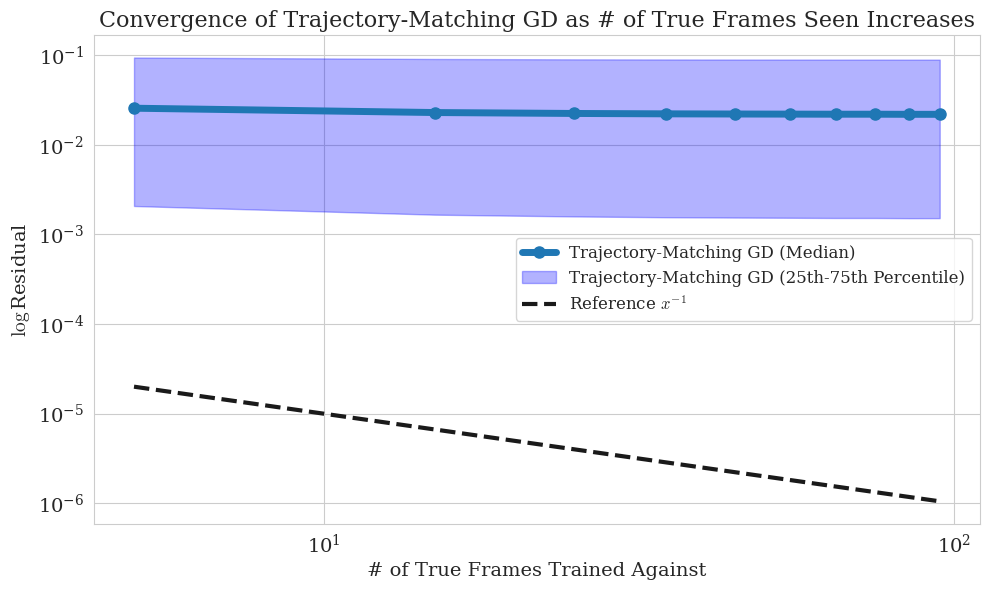

In [103]:
percentiles = np.percentile(residual_samples, [25, 50, 75], axis=1)

plt.figure(figsize=(10, 6))

plt.loglog(x_frames, percentiles[1], marker="o", label="Trajectory-Matching GD (Median)", linewidth=5, markersize=8)
plt.fill_between(x_frames, percentiles[0], percentiles[2], alpha=0.3, label="Trajectory-Matching GD (25th-75th Percentile)", color="blue")
plt.loglog(x_frames, 1/(10000*x_frames), "k--", label=r"Reference $x^{-1}$", linewidth=3)
plt.xlabel("# of True Frames Trained Against")
plt.ylabel(r"$\log$Residual")
plt.title("Convergence of Trajectory-Matching GD as # of True Frames Seen Increases")
plt.legend()
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "residual_trajectory_matching.svg")
plt.show()


### Derivative-Matching

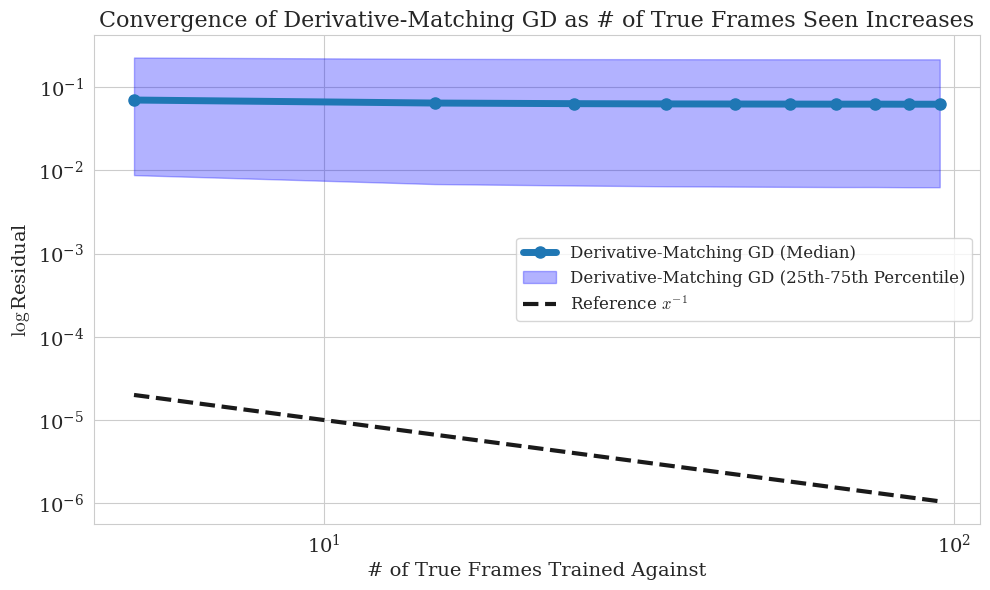

In [104]:
with open(OUTPUT_DIR / "residual_derivative_matching.pkl", "rb") as f:
    data = pkl.load(f)
    
num_frames_list = data["num_frames_list"]
residual_samples = data["residual_samples"]

percentiles = np.percentile(residual_samples, [25, 50, 75], axis=1)

plt.figure(figsize=(10, 6))

plt.loglog(x_frames, percentiles[1], marker="o", label="Derivative-Matching GD (Median)", linewidth=5, markersize=8)
plt.fill_between(x_frames, percentiles[0], percentiles[2], alpha=0.3, label="Derivative-Matching GD (25th-75th Percentile)", color="blue")
plt.loglog(x_frames, 1/(10000*x_frames), "k--", label=r"Reference $x^{-1}$", linewidth=3)
plt.xlabel("# of True Frames Trained Against")
plt.ylabel(r"$\log$Residual")
plt.title("Convergence of Derivative-Matching GD as # of True Frames Seen Increases")
plt.legend()
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "residual_derivative_matching.svg")
plt.show()

### Parameter Cascades Method

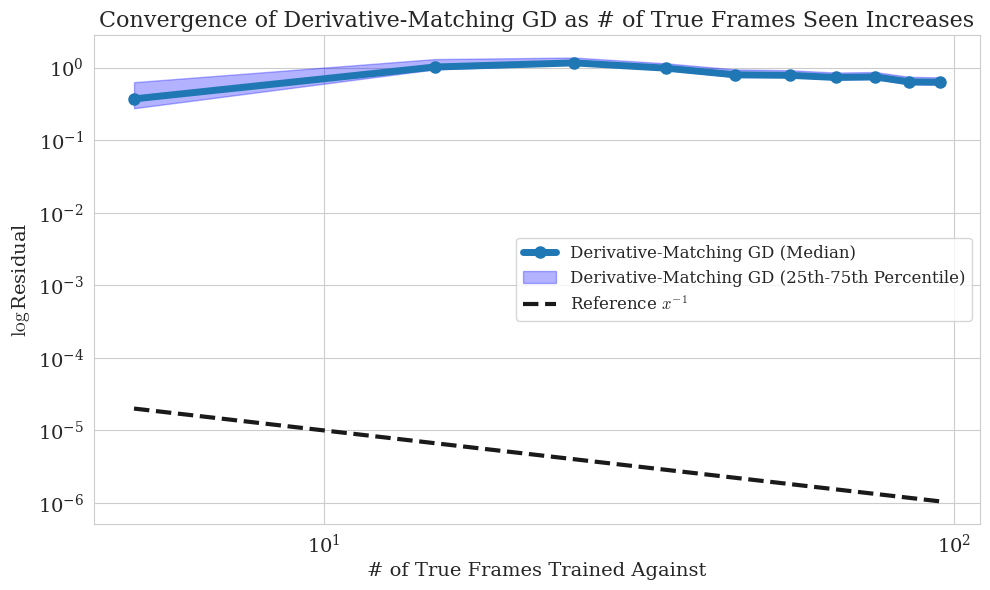

In [105]:
with open(OUTPUT_DIR / "residual_cascade_parameter_estimation.pkl", "rb") as f:
    data = pkl.load(f)
    
num_frames_list = data["num_frames_list"]
residual_samples = data["residual_samples"]

percentiles = np.percentile(residual_samples, [25, 50, 75], axis=1)

plt.figure(figsize=(10, 6))

plt.loglog(x_frames, percentiles[1], marker="o", label="Derivative-Matching GD (Median)", linewidth=5, markersize=8)
plt.fill_between(x_frames, percentiles[0], percentiles[2], alpha=0.3, label="Derivative-Matching GD (25th-75th Percentile)", color="blue")
plt.loglog(x_frames, 1/(10000*x_frames), "k--", label=r"Reference $x^{-1}$", linewidth=3)
plt.xlabel("# of True Frames Trained Against")
plt.ylabel(r"$\log$Residual")
plt.title("Convergence of Derivative-Matching GD as # of True Frames Seen Increases")
plt.legend()
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "residual_derivative_matching.svg")
plt.show()

### All-three Methods together

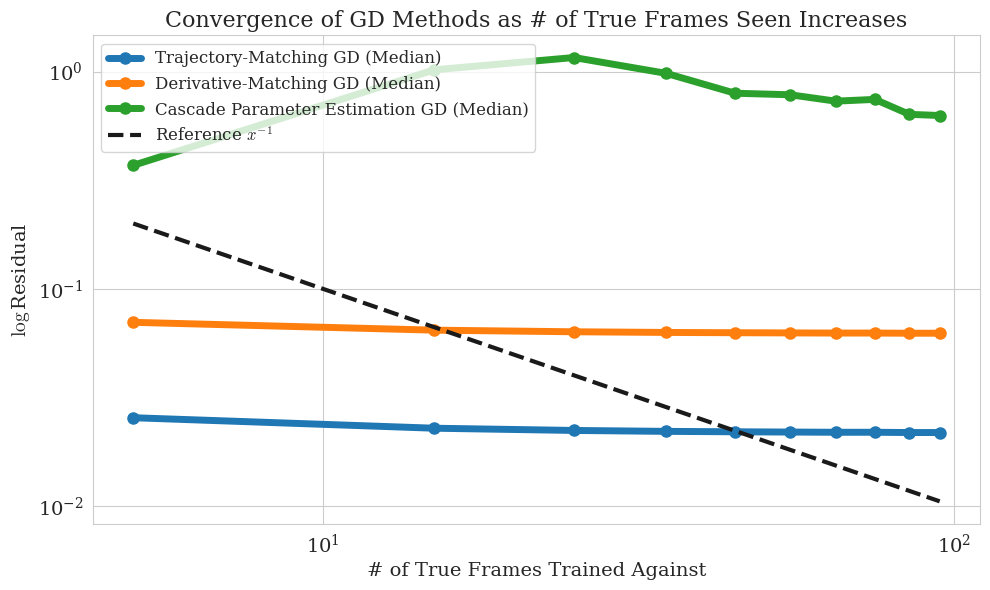

In [106]:
with open(OUTPUT_DIR / "residual_trajectory_matching.pkl", "rb") as f:
    trajectory_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_derivative_matching.pkl", "rb") as f:
    derivative_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_cascade_parameter_estimation.pkl", "rb") as f:
    cascade_data = pkl.load(f)

num_frames_list = cascade_data["num_frames_list"]
trajectory_samples = trajectory_data["residual_samples"]
derivative_samples = derivative_data["residual_samples"]
cascade_samples = cascade_data["residual_samples"]

plt.figure(figsize=(10, 6))

plt.loglog(num_frames_list, np.percentile(trajectory_samples, 50, axis=1), marker="o", label="Trajectory-Matching GD (Median)", linewidth=5, markersize=8)
# plt.fill_between(num_frames_list, np.percentile(trajectory_samples, 25, axis=1), np.percentile(trajectory_samples, 75, axis=1), alpha=0.3, label="Trajectory-Matching GD (25th-75th Percentile)", color="blue")

plt.loglog(num_frames_list, np.percentile(derivative_samples, 50, axis=1), marker="o", label="Derivative-Matching GD (Median)", linewidth=5, markersize=8)
# plt.fill_between(num_frames_list, np.percentile(derivative_samples, 25, axis=1), np.percentile(derivative_samples, 75, axis=1), alpha=0.3, label="Derivative-Matching GD (25th-75th Percentile)", color="orange")

plt.loglog(num_frames_list, np.percentile(cascade_samples, 50, axis=1), marker="o", label="Cascade Parameter Estimation GD (Median)", linewidth=5, markersize=8)
# plt.fill_between(num_frames_list, np.percentile(cascade_samples, 25, axis=1), np.percentile(cascade_samples, 75, axis=1), alpha=0.3, label="Cascade Parameter Estimation GD (25th-75th Percentile)", color="green")

plt.loglog(num_frames_list, 1/(np.array(num_frames_list)), "k--", label=r"Reference $x^{-1}$", linewidth=3)
plt.xlabel("# of True Frames Trained Against")
plt.ylabel(r"$\log$Residual")
plt.title("Convergence of GD Methods as # of True Frames Seen Increases")
plt.legend()
plt.tight_layout()

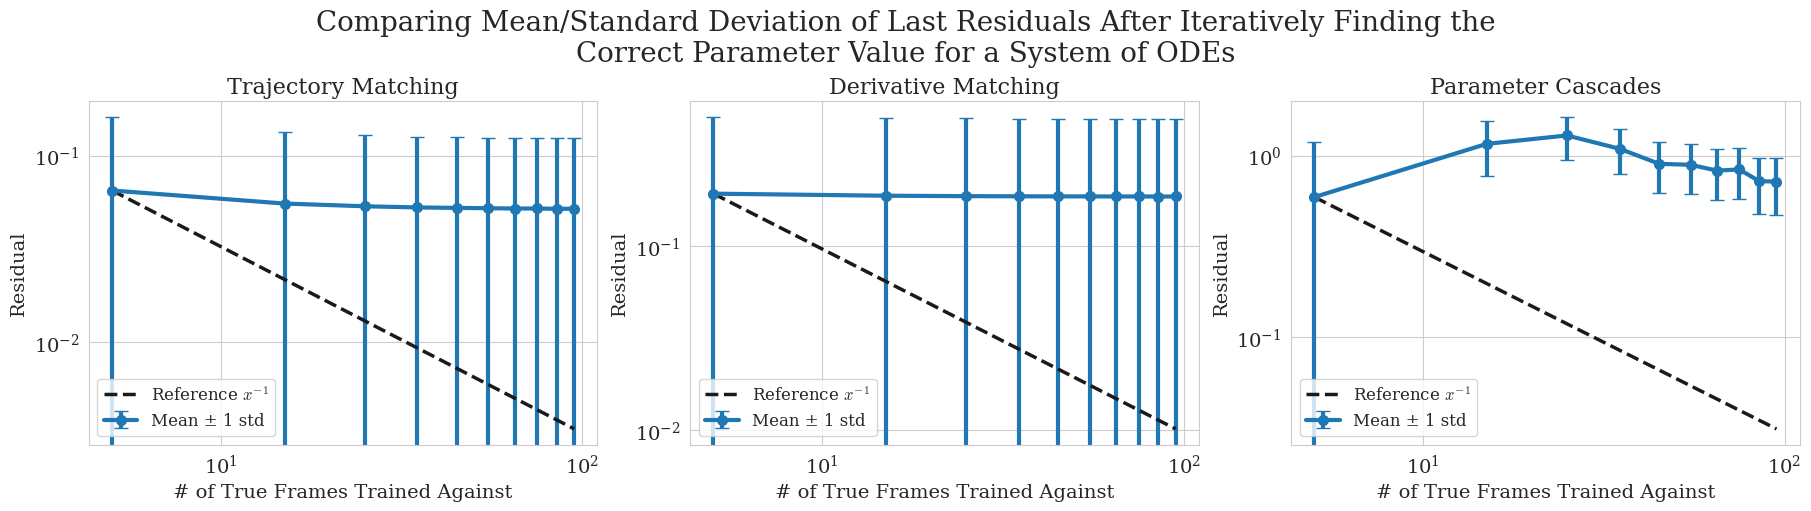

In [112]:
with open(OUTPUT_DIR / "residual_trajectory_matching.pkl", "rb") as f:
    trajectory_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_derivative_matching.pkl", "rb") as f:
    derivative_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_cascade_parameter_estimation.pkl", "rb") as f:
    cascade_data = pkl.load(f)

num_frames_list = cascade_data["num_frames_list"]
trajectory_samples = trajectory_data["residual_samples"]
derivative_samples = derivative_data["residual_samples"]
cascade_samples = cascade_data["residual_samples"]

x = np.array(num_frames_list, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)
cascade_samples = np.array(cascade_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
    ("Parameter Cascades", cascade_samples),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    sample_mean = samples.mean(axis=1)
    sample_std = samples.std(axis=1, ddof=1)

    ax.errorbar(
        x,
        sample_mean,
        yerr=sample_std,
        marker="o",
        linewidth=3,
        markersize=7,
        capsize=5,
        label="Mean ± 1 std",
    )

    # Scale reference 1/x to match the first mean value.
    reference = sample_mean[0] * (x[0] / x)

    ax.loglog(
        x,
        reference,
        "k--",
        linewidth=2.5,
        label=r"Reference $x^{-1}$",
    )

    ax.set_title(title)
    ax.set_xlabel("# of True Frames Trained Against")
    ax.set_ylabel("Residual")
    ax.legend()

# fig.suptitle("Residual vs Number of Observed Frames", fontsize=20)
fig.suptitle("Comparing Mean/Standard Deviation of Last Residuals After Iteratively Finding the\nCorrect Parameter Value for a System of ODEs", fontsize=20)
plt.savefig(OUTPUT_DIR / "residual_methods_by_frames_mean.svg")
plt.show()

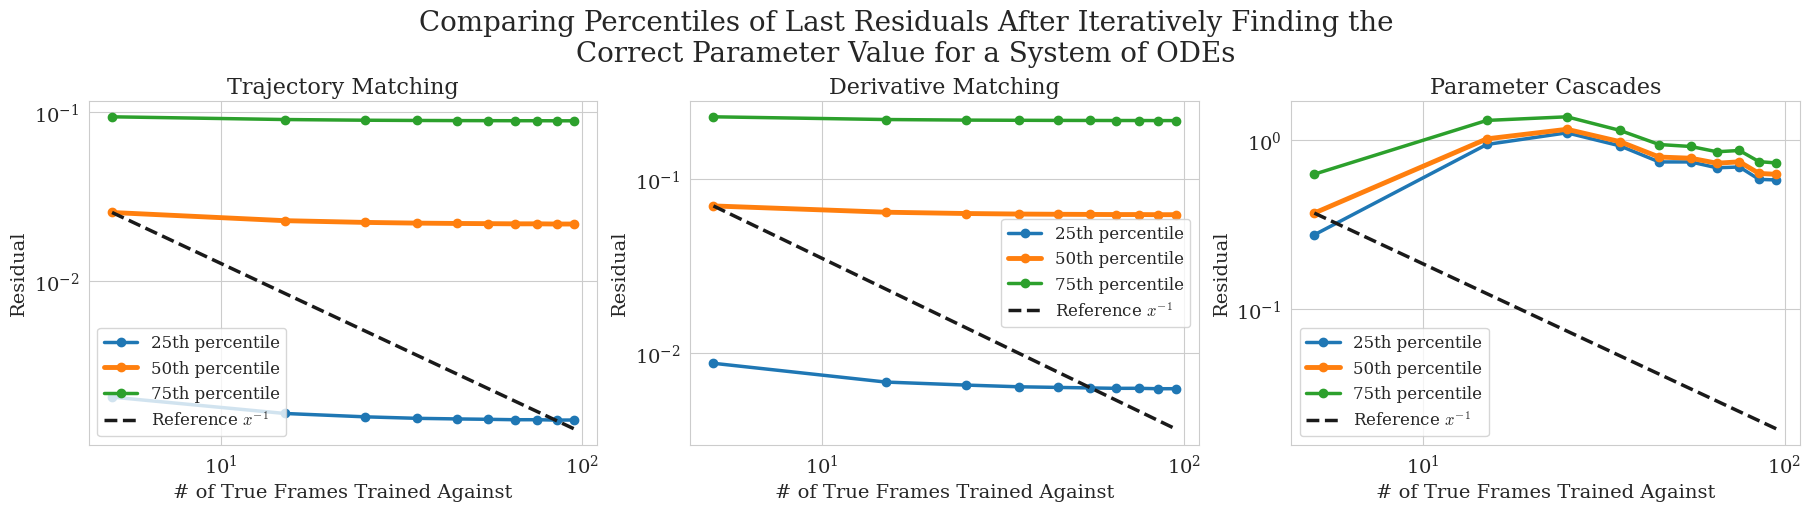

In [113]:
with open(OUTPUT_DIR / "residual_trajectory_matching.pkl", "rb") as f:
    trajectory_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_derivative_matching.pkl", "rb") as f:
    derivative_data = pkl.load(f)

with open(OUTPUT_DIR / "residual_cascade_parameter_estimation.pkl", "rb") as f:
    cascade_data = pkl.load(f)

num_frames_list = cascade_data["num_frames_list"]
trajectory_samples = trajectory_data["residual_samples"]
derivative_samples = derivative_data["residual_samples"]
cascade_samples = cascade_data["residual_samples"]

x = np.array(num_frames_list, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)
cascade_samples = np.array(cascade_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
    ("Parameter Cascades", cascade_samples),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# of True Frames Trained Against")
    ax.set_ylabel("Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Comparing Percentiles of Last Residuals After Iteratively Finding the\nCorrect Parameter Value for a System of ODEs", fontsize=20)
plt.savefig(OUTPUT_DIR / "residual_methods_percentiles_by_frames.svg")
plt.show()

### Comparison by Epoch

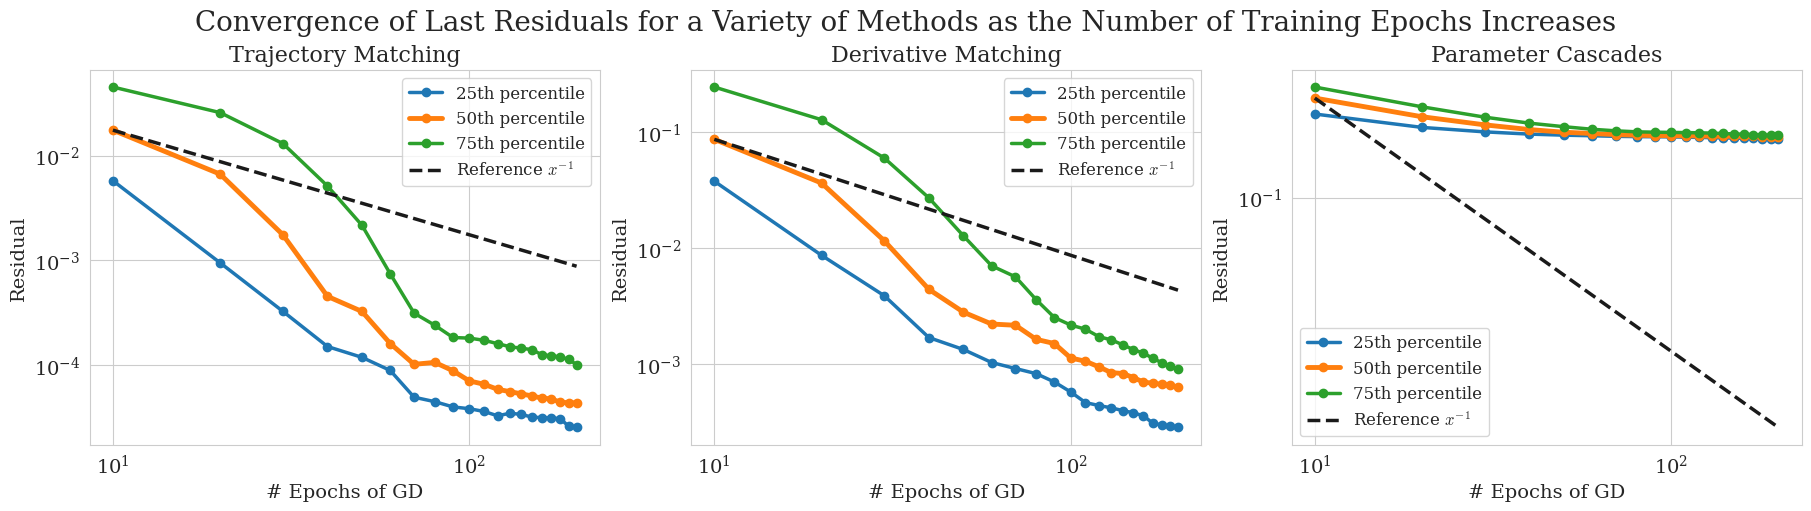

In [118]:
with open(OUTPUT_DIR / "population_parameter_estimation_by_epochs.pkl", "rb") as f:
    epoch_data = pkl.load(f)

epochs = epoch_data["epochs_list"]
results = epoch_data["results"]
trajectory_samples = results["trajectory_matching"]['training_loss']
derivative_samples = results["derivative_matching"]['training_loss']
cascade_samples = results["cascade"]['training_loss']

x = np.array(epochs, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)
cascade_samples = np.array(cascade_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
    ("Parameter Cascades", cascade_samples),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel("Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Convergence of Last Residuals for a Variety of Methods as the Number of Training Epochs Increases", fontsize=20)
plt.savefig(OUTPUT_DIR / "residual_methods_percentiles_by_epochs.svg")
plt.show()

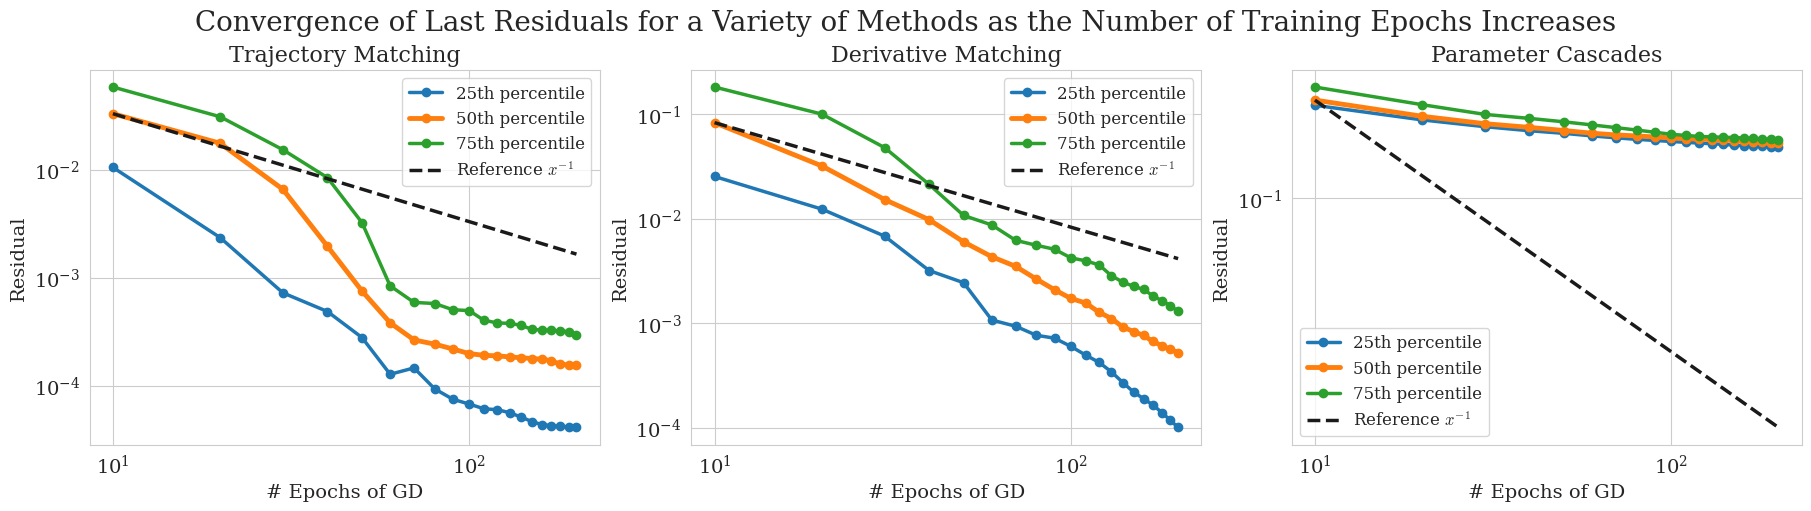

In [119]:
with open(OUTPUT_DIR / "population_parameter_estimation_by_epochs.pkl", "rb") as f:
    epoch_data = pkl.load(f)

epochs = epoch_data["epochs_list"]
results = epoch_data["results"]
trajectory_samples = results["trajectory_matching"]['training_loss']
derivative_samples = results["derivative_matching"]['training_loss']
cascade_samples = results["cascade"]['training_loss']

x = np.array(epochs, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)
cascade_samples = np.array(cascade_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
    ("Parameter Cascades", cascade_samples),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel("Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Convergence of Last Residuals for a Variety of Methods as the Number of Training Epochs Increases", fontsize=20)
plt.savefig(OUTPUT_DIR / "residual_methods_percentiles_by_epochs.svg")
plt.show()

## Advection-Diffusion